## In this module you will learn how to:
- Learn the basics of AI API usage (keys and limits, temperature)
- Learn how to structured outputs from APIs
- See a real-world example of coding text.

This notebook currently doesn't have a student exercise section as it can take a while to run (and sometimes times out).

Historically, a variety of targeted (and somewhat intricate/complex) ML methods for images and text have been used to create structured data from these unstructured data that could be used in modelling. Recently, GenAI (which is more general-purpose and available from an API) has been able to fill this role in a much simpler way.

This demo will show how to use GenAI to create a numerical score from free-form text. Multimodal models that accept images and other forms of unstructured data are also available, and the code to use them is very similar (and AI can assist).

For setup, you you'll need API access to a model. This demo will use the free-tier of Google API. Go to [Google AI Studio](https://aistudio.google.com), click "API Keys" on the left. If you have a default key already created, you can use that. Otherwise, click "Get API key", give it a name, and select "Create API key". If you haven't setup billing this will use the free-tier. **Note: Typical GenAI consumer subscription plans allow the model provider to view and use your data. If your data is sensitive, you may need a plan with more data protections (investigate 'enterprise plans').**

The general process will be to loop over observations, each time proving standard instructions and an unstructured example and then storing the output.


Accuracy/Verification: A sense of accuracy of the conversion can be very helpful.
- A typical way is to spend extra resources to expertly convert a subset of observations, either manually or using a higher-quality model. If there is high disagreement between the base conversions and the expert, it likely makes sense to look at those cases so that you can refine the instructions. You can ask an expert AI model to help improve the instructions. You can even include in the instructions a few examples of input and desired output, a process known as "few shot learning". If disagreement stays high, you can choose a better base model.
- You can also ask the 'base' model output an uncertainty score along with the conversion. See if this lines up with expert disagreement. If it is informative, you can use this uncertainty score in later modelling, e.g., if the conversion is the outcome of a later ML modell lthen you can do weighted regression and have the model care more about accuracy on the observations that are more likely to be right.

For this demo, click on the secrets tab on the left. If it allows you to import your Gemini API key, use that. Otherwise create a new one, give it a name have the value be the API key. Then toggle "Notebook access".

You will need to pick a model, which entails a few key things to think about:
1. Structured output: This is ideal as you can tell the model what the allowed output is. We use it below. Not all models support this. If not, you'll have to convert potentially free-form text to what you want.
2. Rate limits: Depending on your subscription/payment plan you may need to stick below some threshold and explicitly manage that. We use a packe for this.
3. Model performance: You can try several models and see what performs well. Typically better models are more expensive.

We use the new [Gemma 4 models](https://blog.google/innovation-and-ai/technology/developers-tools/gemma-4/) as they are a good combination of performance and affordability.

Finally, Reproducibility: The main control for randomness in a GenAI model is its `temperature` that you can set to 0, which we do. This will improve reproducibility, but not guarantee it due to low-level hardware differences (your task may not always run on the same hardware and may run with other concurrent users). (Note that Google states that "Lower values may impact reasoning", though this is likely for creative tasks.) Also, proprietary models may become unavailable by their provider. 

Note: Colab free-tier has a runtime limit of 12 hours.

In [ ]:
# Do first as you might need some permissions accepted
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install ratelimit

  Preparing metadata (setup.py) ... done
  Created wheel for ratelimit: filename=ratelimit-2.2.1-py3-none-any.whl size=5893 sha256=ee68b6b723aee101a8cac8e611a9e75c03fac2e47f17bf561b32dac01a466fc2
  Stored in directory: /root/.cache/pip/wheels/69/bd/e0/4a5dee2a1bfbc8e258f543f92940e2b494d63b5be8144ec8c4
Successfully built ratelimit


In [ ]:
# Load the API key
from google.colab import userdata
api_key = userdata.get('GEMINI_API_KEY')
#api_key = os.environ.get("GEMINI_API_KEY")

In [ ]:
# Download the latest version of a dataset
import kagglehub
path = kagglehub.dataset_download("drlexus/fed-statements-and-minutes")

fname = "Fed_Scrape-2015-2023.csv"

100%|██████████| 1.16M/1.16M [00:00<00:00, 41.1MB/s]

Extracting files...


In [ ]:
# import the data. Use just the statements for now
import pandas as pd
df = pd.read_csv(path + "/" + fname, parse_dates=["Date"], date_format="%Y%m%d", dtype={'Text':"string"})
df = df.iloc[:,1:].rename(columns={'Type':'is_meeting_minutes'}) #remove index col. Type=0 represents a statement, while 1 represents meeting minutes
print(df.dtypes)
print(df.shape)
display(df.head(1))
print(f"is_meeting_minutes mean={df['is_meeting_minutes'].mean()}")

df_s = df[df['is_meeting_minutes']==0]
print(df_s.shape)

Date                  datetime64[ns]
is_meeting_minutes             int64
Text                  string[python]
dtype: object
(9974, 3)


,Date,is_meeting_minutes,Text
0,2023-04-12,0,The Federal Reserve on Wednesday released the ...


is_meeting_minutes mean=0.8266492881491879
(1729, 3)


In [ ]:
# Calling the model
from google import genai
from google.genai import types
from pydantic import BaseModel, Field
from enum import IntEnum
from ratelimit import limits, sleep_and_retry

client = genai.Client(api_key=api_key)
class Sentiment(IntEnum):
  HAWKISH = 1
  NEUTRAL = 2
  DOVISH = 3

class FOMCSentiment(BaseModel):
    sentiment: Sentiment = Field(description="The score.")

# What model to use?
# gemini-3-flash-preview: Free-tier has a RPM limit of 5 and RPD limit of 20!!
gemini3_rpd_limit=18 # technically 20
gemini3_rpm_limit=3 # technically 5, but was running into problems
@sleep_and_retry
@limits(calls=3, period=55) #extra buffer on time
def generate_gemma4(client, content, model = "gemini-3-flash-preview", temperature=1.0):
  response = client.models.generate_content(
      model=model,
      contents=content,
      config={
          "response_mime_type": "application/json",
          "response_json_schema": FOMCSentiment.model_json_schema(),
          "temperature": temperature, # from 0 to 2
      },
  )
  return FOMCSentiment.model_validate_json(response.text)

# Gemma 4:
#Could go down to gemma 3 for 14.4k RPD
gemma4_rpd_limit = 1498 #technically 1500
gemma4_rpm_limit = 12 # technically 15, but have a buffer as was running into problems
@sleep_and_retry
@limits(calls=gemma4_rpm_limit, period=55) #extra buffer for period
def generate_gemma4(client, content, model = "gemma-4-26b-a4b-it", temperature=1.0):
  #model=gemma-4-31b-it
  response = client.models.generate_content(
      model=model,
      contents=content,
      config={
          "response_mime_type": "application/json",
          "response_json_schema": FOMCSentiment.model_json_schema(),
          "temperature": temperature, # from 0 to 2
      },
  )
  return FOMCSentiment.model_validate_json(response.text)

# Sometimes rate limit seems a bit aggressive (even after using ratelimit pkg), so try an extra catch-retry here
def generate_gemma4_wr(*args, **kwargs):
  try:
    return generate_gemma4(*args, **kwargs)
  except ClientError as e:
    import time
    time.sleep(65)
    # print("Client error, trying once.")
    return generate_gemma4(*args, **kwargs)

I wrote an initial instructions script and then gave it and my goals to an AI and had it improve them.

In [ ]:
instructions = ("You are an expert macroeconomist specializing in central bank communications.\n"
"Your task is to analyze Federal Open Market Committee (FOMC) statements and classify their sentiment.\n\n"
"### Context and Definitions:\n- **FOMC's Dual Mandate**: Maximum employment (low unemployment) and price stability (below target of 2% inflation). FOMC's main instrument is monetary policy that affects key interest rates (e.g., Fed Funds target range), either by buy/selling debt or paying banks interest on their reserves with the Federal Reserve. Low interest rates stimulate more economic growth and high interest rates stifle economic growth.The two mandates are often in tension, as a fast growing economy (that promotes full employment) may create inflation above target.\n- **FOMC statement**: The FOMC uses its statements to set market expectations about how it expects to affect monetary policy in the future.\n- **Hawkish (1)**: Focuses on controlling inflation. Signals tighter monetary policy, higher interest rates, or concerns about an overheating economy.\n- **Neutral (2)**: Indicates a balanced view of risks or a 'wait-and-see' approach with no clear bias toward tightening or easing.\n- **Dovish (3)**: Focuses on supporting employment and growth. Signals looser monetary policy, lower interest rates, or concerns about economic weakness/disinflation.\n\n"
"### Examples:\n- **Hawkish**: \"The Committee remains highly attentive to inflation risks and anticipates that ongoing increases in the target range will be appropriate.\"\n- **Dovish**: \"Economic activity has slowed from its strong pace. The Committee will closely monitor incoming information and is prepared to adjust monetary policy as appropriate to support the recovery.\n\n"
"### Task:\nuse the above schema to categorize the follow FOMC text:\n\n")

## Convert some samples.

Colab might stop unexpectedly after long runs (you might have to keep the webclient active (not sleeping)). Commented code below can be used to save predictions periodically, and then you can restart from a mid-point.

In [ ]:
# Might have to keep web client open otherwise Colab might stop. You can try to backup the predicitons to a pickle
# Convert some samples
import numpy as np
import pickle
from tqdm import tqdm
from google.genai.errors import ClientError # Import ClientError for specific exception handling

colab_runtime_limit = 12*60 #in minutes. 12 hours
n_convert = min(gemma4_rpd_limit, df_s.shape[0], int(colab_runtime_limit*gemma4_rpm_limit*.9)) #give a buffer on colab runtime
sentiments = np.empty(n_convert, dtype=int)

#int_fname ='data.pkl'
#with open(int_fname, 'rb') as file:
#    sentiments = pickle.load(file)
#start = sentiments.shape[0]
start = 0

for i in tqdm(range(start, n_convert)):
  content = f"{instructions}\n{df_s['Text'].iloc[i]}"
  x = generate_gemma4_wr(client, content, temperature=0)
  sentiments[i] = x.sentiment.value
  #if (i%50)==0:
  #  with open(int_fname, 'wb') as file:
  #    pickle.dump(sentiments, file)


  1%|          | 16/1498 [00:56<2:17:14,  5.56s/it]

Client error, trying once.


  3%|▎         | 48/1498 [03:57<43:42,  1.81s/it]

Client error, trying once.


  4%|▍         | 64/1498 [05:59<2:12:30,  5.54s/it]

...

 98%|█████████▊| 1461/1498 [2:36:05<02:33,  4.14s/it]

Client error, trying once.


100%|█████████▉| 1492/1498 [2:39:04<00:13,  2.26s/it]

Client error, trying once.


100%|██████████| 1498/1498 [2:40:13<00:00,  6.42s/it]


In [ ]:
# Bring the data together and see a summary
df_s2 = df_s.iloc[:n_convert].copy()
df_s2["Sentiment"] = sentiments
print(df_s2["Sentiment"].mean())
df_s2.to_parquet('/content/drive/MyDrive/' + 'FOMC_sentiment.parquet')
#df_s2 = pd.read_parquet('/content/drive/MyDrive/' + 'FOMC_sentiment.parquet')
display(df_s2)

2.0587449933244324


,Date,is_meeting_minutes,Text,Sentiment
0,2023-04-12,0,The Federal Reserve on Wednesday released the ...,2
1,2023-04-12,0,The minutes for each regularly scheduled meeti...,2
2,2023-04-12,0,The minutes can be viewed on the Board's website.,2
3,2023-04-12,0,"For media inquiries, e-mail [email protected] ...",2
4,2023-04-12,0,Minutes of the Federal Open Market Committee ...,2
...,...,...,...,...
8884,2015-12-03,0,The awarded deposits will settle on D...,2
8885,2015-12-03,0,"For media inquiries, call 202-452-2955...",2
8886,2015-12-02,0,"On December 3, 2015, the Federal Reserve will ...",2
8887,2015-12-02,0,Description of Operation and Tender Parameters,2


<Axes: >

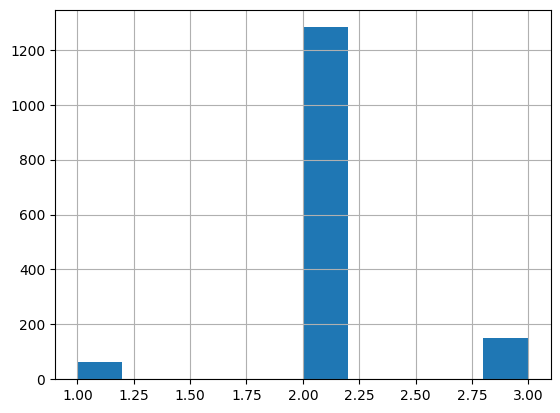

In [ ]:
df_s2['Sentiment'].hist()

In [ ]:
# Correlate with interest rates??
# path = kagglehub.dataset_download("federalreserve/interest-rates")

In [12]:
# Reproducibility info
import sys, numpy as np, pandas as pd, matplotlib, kagglehub, google, pydantic, ratelimit
from google import genai
print(f'Python:       {sys.version}')
print(f'NumPy:        {np.__version__}')
print(f'Pandas:       {pd.__version__}')
print(f'Matplotlib:   {matplotlib.__version__}')
print(f'kagglehub: {kagglehub.__version__}')
print(f'google colab: {google.colab.__version__}')
print(f'google genai: {genai.version.__version__}')
print(f'pydantic: {pydantic.__version__}')
print(f'ratelimit: {ratelimit.__version__}')

Python:       3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
NumPy:        2.0.2
Pandas:       2.2.2
Matplotlib:   3.10.0
kagglehub: 1.0.0
google colab: 0.0.1a2
google genai: 1.68.0
pydantic: 2.12.3
ratelimit: 2.2.1
